__[cosmograph learning](https://github.com/apowers313/roc/blob/master/experiments/2025.04.26-10.35.32-cosmograph-learning/2025.04.26-10.35.32-cosmograph-learning.ipynb)__

In [ ]:
!date

In [ ]:
# save notebook path before we get started
import os

notebook_path = os.path.abspath("")  # not sure if this or os.getcwd() is more reliable

### Cosmograph Hello World

https://cosmograph.app/docs/cosmograph/Cosmograph%20Python/get-started-widget/

In [1]:
import pandas as pd
from cosmograph import cosmo

points = pd.DataFrame(
    {
        "id": [1, 2, 3, 4, 5],
        "label": ["Node A", "Node B", "Node C", "Node D", "Node E"],
        "value": [10, 20, 15, 25, 30],
        "category": ["A", "B", "A", "B", "A"],
    }
)

links = pd.DataFrame(
    {"source": [1, 2, 3, 1, 2], "target": [2, 3, 4, 5, 4], "value": [1.0, 2.0, 1.5, 0.5, 1.8]}
)

widget = cosmo(
    points=points,
    links=links,
    point_id_by="id",
    link_source_by="source",
    link_target_by="target",
    point_color_by="category",
    point_include_columns=["value"],
    point_label_by="label",
    link_include_columns=["value"],
)
widget

Cosmograph(background_color=None, focused_point_ring_color=None, hovered_point_ring_color=None, link_color=Non…

# Sample Graph

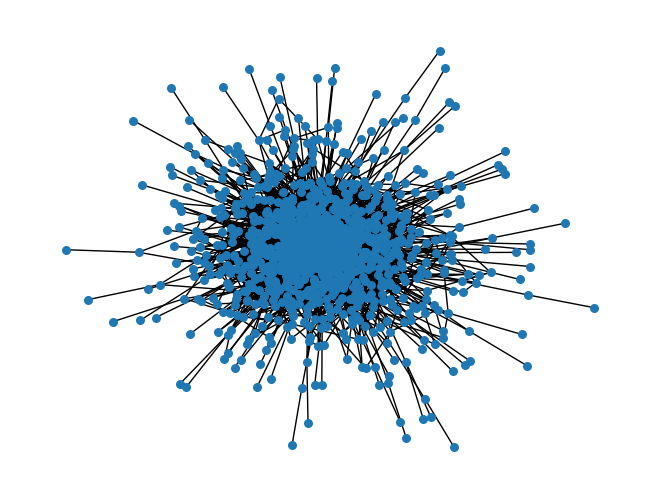

In [1]:
import networkx as nx
from random import random
import math

num_nodes = 1000
time_step_probability = 0.2
new_edge_probability = 0.8
time_step = 1

G = nx.Graph()


def rand_node():
    nodes = [n for n in G]
    num_nodes = len(nodes)
    if num_nodes < 1:
        return None
    idx = math.floor(num_nodes * random())
    ret = nodes[idx]
    return ret


def is_connected(n1, n2):
    return n2 in G.neighbors(n1)


cnt = 0
while cnt < num_nodes:
    if random() < time_step_probability:
        time_step += 1

    if cnt > 3 and random() < new_edge_probability:
        n1 = rand_node()
        n2 = rand_node()
        if n1 is n2 or is_connected(n1, n2):
            continue
        G.add_edge(n1, n2, timestamp=time_step)
    else:
        old_node = rand_node()
        G.add_node(cnt, timestamp=time_step)
        if old_node is not None:
            G.add_edge(old_node, cnt, timestamp=time_step)
        cnt += 1

pos = nx.spring_layout(G, scale=0.5)
nx.draw(G, pos, node_size=30)

## To Pandas

In [4]:
import pandas as pd

node_df = pd.DataFrame(columns=["node_id", "timestamp"])
for n in G:
    # append row
    node_df.loc[len(node_df)] = [n, G.nodes[n]["timestamp"]]

edge_df = pd.DataFrame(columns=["src_node_id", "dst_node_id", "timestamp"])
for src, dst, data in G.edges(data=True):
    edge_df.loc[len(edge_df)] = [src, dst, data["timestamp"]]

print(node_df)
print(edge_df)

     node_id  timestamp
0          0          1
1          1          1
2          2          1
3          3          2
4          4          3
..       ...        ...
995      995        906
996      996        906
997      997        909
998      998        909
999      999        910

[1000 rows x 2 columns]
      src_node_id  dst_node_id  timestamp
0               0            1          1
1               0            2          1
2               0            5          4
3               0            3          4
4               0            4          4
...           ...          ...        ...
4510          905          959        879
4511          922          991        906
4512          946          976        891
4513          957          963        880
4514          967          987        899

[4515 rows x 3 columns]


## Binned

<Axes: xlabel='time', ylabel='changes'>

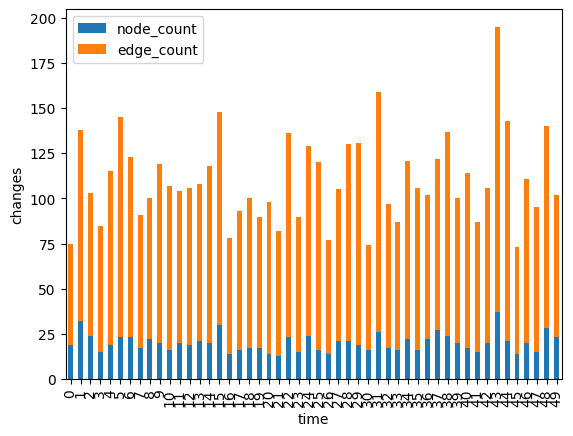

In [3]:
node_bins, bins = pd.cut(node_df["timestamp"], 50, retbins=True)

# print(node_bins)
# bins

node_bin_count = node_bins.value_counts(sort=False)
node_bin_count = node_bin_count.reset_index()
node_bin_count = node_bin_count.rename({"count": "node_count"})
# node_bin_count

edge_bins = pd.cut(edge_df["timestamp"], bins)

edge_bin_count = edge_bins.value_counts(sort=False)
edge_bin_count = edge_bin_count.reset_index()
# edge_bin_count

binned_timeline = pd.concat([node_bin_count, edge_bin_count["count"]], axis=1)
binned_timeline.columns.values[1] = "node_count"
binned_timeline.columns.values[2] = "edge_count"
# binned_timeline

binned_timeline.plot(kind="bar", stacked=True, xlabel="time", ylabel="changes")

# My Graph

In [5]:
import pandas as pd
from cosmograph import cosmo

# points = pd.DataFrame({
#     'id': [1, 2, 3, 4, 5],
#     'label': ['Node A', 'Node B', 'Node C', 'Node D', 'Node E'],
#     'value': [10, 20, 15, 25, 30],
#     'category': ['A', 'B', 'A', 'B', 'A']
# })

# links = pd.DataFrame({
#     'source': [1, 2, 3, 1, 2],
#     'target': [2, 3, 4, 5, 4],
#     'value': [1.0, 2.0, 1.5, 0.5, 1.8]
# })

widget = cosmo(
    points=node_df,
    links=edge_df,
    point_id_by="node_id",
    link_source_by="src_node_id",
    link_target_by="dst_node_id",
    # point_color_by='category',
    # point_include_columns=['value'],
    # point_label_by='label',
    # link_include_columns=['value'],
)

widget

Cosmograph(background_color=None, focused_point_ring_color=None, hovered_point_ring_color=None, link_color=Non…